# Import Depedencies

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.4 MB/s eta 0:00:00


In [ ]:
# ── Standard Library ──────────────────────────────────────────────────────────
import re
import time
import warnings
warnings.filterwarnings('ignore')

# ── Kaggle Library ──────────────────────────────────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter

# ── Data Manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from xgboost import XGBClassifier

# ── Model Persistence ─────────────────────────────────────────────────────────
import joblib

# ── Download NLTK Resources ───────────────────────────────────────────────────
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print('✅ Semua library berhasil diimport!')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ Semua library berhasil diimport!


# Load Data & EDA

In [ ]:
import kagglehub
import pandas as pd

# 1. Download atau pastikan dataset sudah terunduh (mengembalikan path folder)
path = kagglehub.dataset_download("saurabhshahane/ecommerce-text-classification")

# 2. Gabungkan path folder dengan nama file CSV spesifiknya
file_path = f"{path}/ecommerceDataset.csv"

# 3. Baca menggunakan pandas dengan parameter names untuk memberi judul kolom
df = pd.read_csv(file_path, names=["category", "text"])

# 4. Tampilkan 5 data teratas
df.head()

100%|██████████| 7.86M/7.86M [00:01<00:00, 5.43MB/s]

Extracting files...


,category,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


In [ ]:
print(f'Shape dataset : {df.shape}')
print(f'Jumlah kelas  : {df["category"].nunique()}')
print()
df.head(10)

Shape dataset : (50425, 2)
Jumlah kelas  : 4



,category,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...
5,Household,Pitaara Box Romantic Venice Canvas Painting 6m...
6,Household,Paper Plane Design Starry Night Vangoh Wall Ar...
7,Household,Pitaara Box Romantic Venice Canvas Painting 6m...
8,Household,SAF 'Ganesh Modern Art Print' Painting (Synthe...
9,Household,Paintings Villa UV Textured Modern Art Print F...


In [ ]:
# ── Info & Missing Values ─────────────────────────────────────────────────────
print('=== Info Dataset ===')
df.info()
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  50425 non-null  object
 1   text      50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB

=== Missing Values ===
category    0
text        1
dtype: int64


In [ ]:
# ── Statistik Deskriptif ──────────────────────────────────────────────────────
print('=== Distribusi Kelas ===')
print(df['category'].value_counts())
print()

# Panjang teks
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count']  = df['text'].astype(str).apply(lambda x: len(x.split()))

print('=== Statistik Panjang Teks ===')
print(df.groupby('category')[['text_length', 'word_count']].describe().round(2))

=== Distribusi Kelas ===
category
Household                 19313
Books                     11820
Electronics               10621
Clothing & Accessories     8671
Name: count, dtype: int64

=== Statistik Panjang Teks ===
                       text_length                                      \
                             count    mean      std  min    25%    50%   
category                                                                 
Books                      11820.0  857.01  1624.80  4.0   81.0  495.0   
Clothing & Accessories      8671.0  446.25   393.47  3.0  181.0  342.0   
Electronics                10621.0  851.11   813.68  9.0  293.0  630.0   
Household                  19313.0  671.54   606.38  8.0  274.0  515.0   

                                        word_count                             \
                           75%      max      count    mean     std  min   25%   
category                                                                        
Books             

# Visualisasi

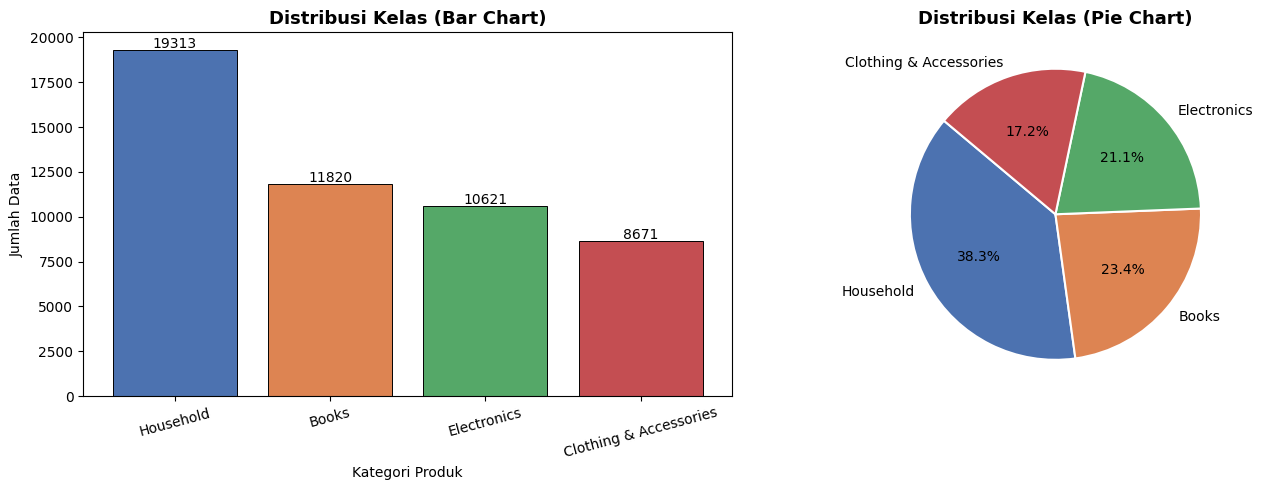

✅ Gambar disimpan: distribusi_kelas.png


In [ ]:
# ── Visualisasi Distribusi Kelas ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['category'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribusi Kelas (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kategori Produk')
axes[0].set_ylabel('Jumlah Data')
for i, (cat, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 100, str(val), ha='center', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Distribusi Kelas (Pie Chart)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: distribusi_kelas.png')

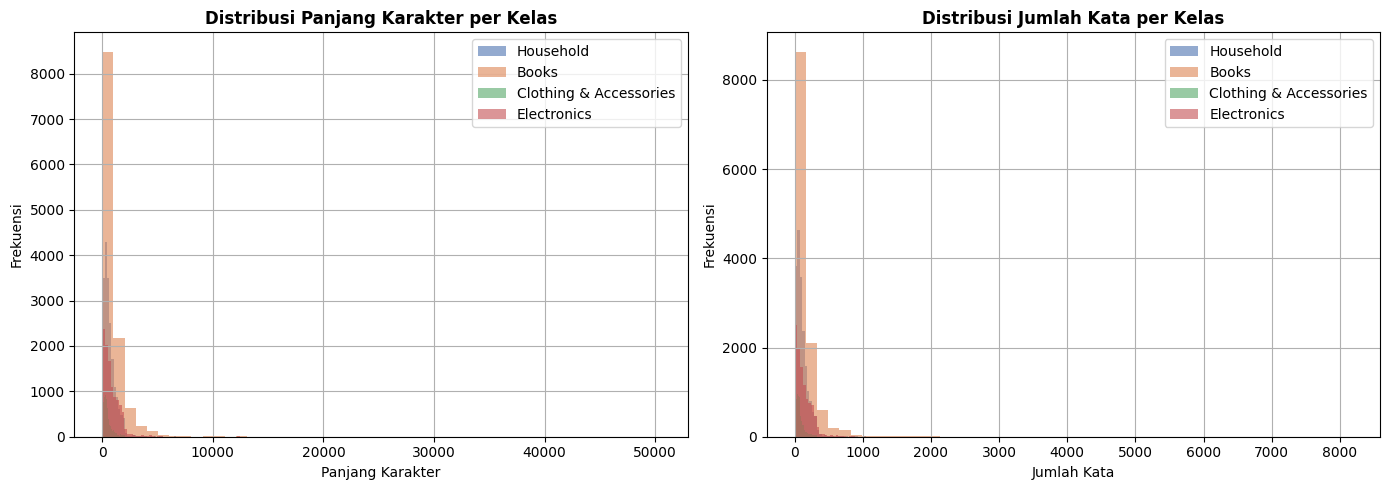

In [ ]:
# ── Distribusi Panjang Teks per Kelas ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['text_length', 'word_count'],
                           ['Panjang Karakter', 'Jumlah Kata']):
    for label, color in zip(df['category'].unique(), colors):
        subset = df[df['category'] == label][col]
        subset.hist(ax=ax, bins=50, alpha=0.6, label=label, color=color)
    ax.set_title(f'Distribusi {title} per Kelas', fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.tight_layout()
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

# Preprocessing

In [ ]:
# ── Inisialisasi Tools ────────────────────────────────────────────────────────
stop_words  = set(stopwords.words('english'))
stemmer     = PorterStemmer()
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text: str, use_stemming: bool = False) -> str:
    """
    Pipeline pra-pemrosesan teks:
      1. Case folding (lowercase)
      2. Hapus HTML tags
      3. Hapus karakter non-alfabet & angka
      4. Tokenisasi
      5. Stopword removal
      6. Lemmatization (default) atau Stemming
    """
    # 1. Lowercase
    text = str(text).lower()
    # 2. Hapus HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # 3. Hapus karakter khusus & angka (simpan huruf & spasi)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. Tokenisasi
    tokens = word_tokenize(text)
    # 5. Stopword removal & token pendek
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 6. Stemming / Lemmatization
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)

# ── Preview ───────────────────────────────────────────────────────────────────
sample = df['text'].iloc[0]
print('ORIGINAL :', sample[:200])
print()
print('PROCESSED:', preprocess_text(sample)[:200])

ORIGINAL : Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attract

PROCESSED: paper plane design framed wall hanging motivational office decor art print inch set painting made synthetic frame textured print give multi effect attracts towards special series painting make wall be


In [ ]:
# ── Terapkan Pra-pemrosesan ke Seluruh Dataset ────────────────────────────────
# Gunakan lemmatization (use_stemming=False)
print('Memproses teks... (mungkin butuh beberapa menit)')
t0 = time.time()
df['text_clean'] = df['text'].apply(lambda x: preprocess_text(x, use_stemming=False))
print(f'✅ Selesai dalam {time.time()-t0:.1f} detik')

# Hapus baris kosong setelah preprocessing
df = df[df['text_clean'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Shape setelah preprocessing: {df.shape}')
df[['category', 'text', 'text_clean']].head(5)

Memproses teks... (mungkin butuh beberapa menit)
✅ Selesai dalam 35.1 detik
Shape setelah preprocessing: (50425, 5)


,category,text,text_clean
0,Household,Paper Plane Design Framed Wall Hanging Motivat...,paper plane design framed wall hanging motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",saf floral framed painting wood inch inch spec...
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,saf textured modern art print framed painting ...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",saf flower print framed painting synthetic inc...
4,Household,Incredible Gifts India Wooden Happy Birthday U...,incredible gift india wooden happy birthday un...


In [ ]:
# ── Simpan Dataset Bersih ─────────────────────────────────────────────────────
df[['category', 'text_clean']].to_csv('ecommerce_clean.csv', index=False)
print('✅ Dataset bersih disimpan: ecommerce_clean.csv')

✅ Dataset bersih disimpan: ecommerce_clean.csv


# Word Cloud

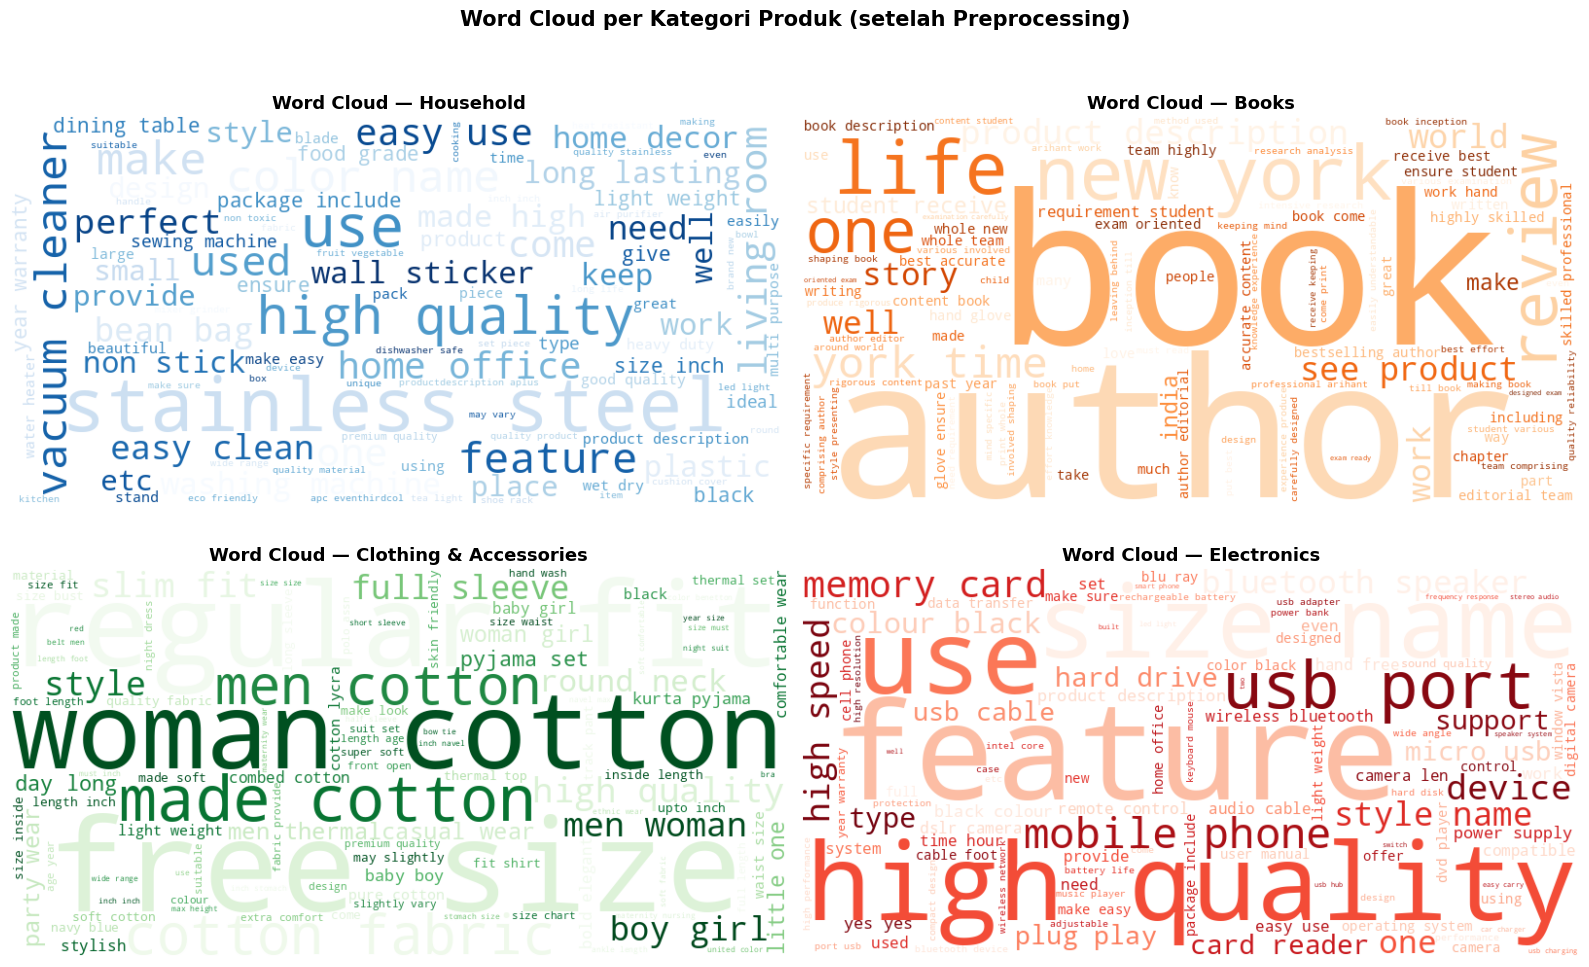

✅ Gambar disimpan: wordcloud_per_kategori.png


In [ ]:
# ── Word Cloud per Kategori ───────────────────────────────────────────────────
categories = df['category'].unique()
wc_colors  = ['Blues', 'Oranges', 'Greens', 'Reds']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (cat, cmap) in enumerate(zip(categories, wc_colors)):
    corpus = ' '.join(df[df['category'] == cat]['text_clean'])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=cmap,
        max_words=100
    ).generate(corpus)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud — {cat}', fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Cloud per Kategori Produk (setelah Preprocessing)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('wordcloud_per_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: wordcloud_per_kategori.png')

# Modeling

## Data Spliting

In [ ]:
# ── Label Encoding ────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['category'])

print('Mapping kelas:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx} → {cls}')

RANDOM_STATE = 42

# ── Split teks mentah (sebelum vectorization) ─────────────────────────────────
# Split dilakukan pada level teks bersih agar vectorizer hanya fit pada train
X_text = df['text_clean'].values

X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Buat sub-dataframe train untuk keperluan visualisasi (word cloud)
train_idx  = pd.Series(range(len(df))).sample(frac=0.8, random_state=RANDOM_STATE).index  # hanya untuk viz
df_train_viz = df.iloc[
    train_test_split(range(len(df)), test_size=0.2, random_state=RANDOM_STATE, stratify=y)[0]
]

print(f'Training set : {len(X_text_train)} sampel')
print(f'Testing set  : {len(X_text_test)} sampel')
print()
print('Distribusi kelas training:')
unique, counts = np.unique(y_train, return_counts=True)
for cls_name, cnt in zip(le.classes_, counts):
    print(f'  {cls_name}: {cnt}')

Mapping kelas:
  0 → Books
  1 → Clothing & Accessories
  2 → Electronics
  3 → Household
Training set : 40340 sampel
Testing set  : 10085 sampel

Distribusi kelas training:
  Books: 9456
  Clothing & Accessories: 6937
  Electronics: 8497
  Household: 15450


## Representasi Fitur

In [ ]:
# ── TF-IDF: fit HANYA pada train, transform pada keduanya ───────────────────
print('Membuat TF-IDF features...')
tfidf_vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True
)
# fit_transform pada train → belajar vocabulary & IDF dari train saja
X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)
# transform pada test → hanya terapkan vocabulary yang sudah dipelajari
X_tfidf_test  = tfidf_vectorizer.transform(X_text_test)

print(f'✅ Shape TF-IDF train : {X_tfidf_train.shape}')
print(f'✅ Shape TF-IDF test  : {X_tfidf_test.shape}')

Membuat TF-IDF features...
✅ Shape TF-IDF train : (40340, 50000)
✅ Shape TF-IDF test  : (10085, 50000)


In [ ]:
# ── Word2Vec: latih HANYA dari kalimat training ──────────────────────────────
print('Melatih Word2Vec dari data training...')
train_sentences = [text.split() for text in X_text_train]

w2v_model = Word2Vec(
    train_sentences,
    vector_size=200,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    seed=42
)

def text_to_w2v(text: str, model: Word2Vec, vector_size: int = 200) -> np.ndarray:
    """Rata-rata vektor kata dari Word2Vec untuk sebuah teks."""
    words = text.split()
    vecs  = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

# Transform train dan test menggunakan model yang sama
X_w2v_train = np.array([text_to_w2v(t, w2v_model) for t in X_text_train])
X_w2v_test  = np.array([text_to_w2v(t, w2v_model) for t in X_text_test])

print(f'✅ Shape Word2Vec train : {X_w2v_train.shape}')
print(f'✅ Shape Word2Vec test  : {X_w2v_test.shape}')

# Simpan model Word2Vec
w2v_model.save('word2vec_ecommerce.model')
print('✅ Word2Vec model disimpan: word2vec_ecommerce.model')

Melatih Word2Vec dari data training...
✅ Shape Word2Vec train : (40340, 200)
✅ Shape Word2Vec test  : (10085, 200)
✅ Word2Vec model disimpan: word2vec_ecommerce.model


## Train & Evaluation

In [ ]:
# ── Definisi Model ────────────────────────────────────────────────────────────
models = {
    'Naive Bayes'        : MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'SVM (LinearSVC)'    : LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost'            : XGBClassifier(n_estimators=200, use_label_encoder=False,
                                          eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE)
}

# ── Fungsi Evaluasi ───────────────────────────────────────────────────────────
def evaluate_model(name, model, X_train, X_test, y_train, y_test, feature_type):
    """Melatih model dan mengembalikan dict metrik evaluasi."""
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)

    result = {
        'Model'       : name,
        'Feature'     : feature_type,
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred, average='weighted'),
        'Recall'      : recall_score(y_test, y_pred, average='weighted'),
        'F1-Score'    : f1_score(y_test, y_pred, average='weighted'),
        'Train Time'  : train_time,
        'y_pred'      : y_pred
    }
    return result

print('Definisi model & fungsi evaluasi siap ✅')

Definisi model & fungsi evaluasi siap ✅


### TF-IDF

In [ ]:
# ── Training & Evaluasi — TF-IDF ──────────────────────────────────────────────
results_tfidf = []

print('=== Training dengan TF-IDF ===')
for name, model in models.items():
    # Naive Bayes tidak bisa dengan negatif → hanya TF-IDF
    print(f'  [{name}] training...', end='')
    r = evaluate_model(name, model, X_tfidf_train, X_tfidf_test,
                        y_train, y_test, 'TF-IDF')
    results_tfidf.append(r)
    print(f' Acc={r["Accuracy"]:.4f} | F1={r["F1-Score"]:.4f} | {r["Train Time"]:.1f}s')

print('\n✅ Selesai!')

=== Training dengan TF-IDF ===
  [Naive Bayes] training... Acc=0.9495 | F1=0.9495 | 0.0s
  [Logistic Regression] training... Acc=0.9678 | F1=0.9677 | 10.8s
  [SVM (LinearSVC)] training... Acc=0.9802 | F1=0.9802 | 1.3s
  [Random Forest] training... Acc=0.9732 | F1=0.9732 | 154.2s
  [XGBoost] training... Acc=0.9701 | F1=0.9700 | 417.4s

✅ Selesai!


### Word2Vec

In [ ]:
# ── Training & Evaluasi — Word2Vec ────────────────────────────────────────────
# Naive Bayes tidak mendukung fitur negatif (Word2Vec bisa menghasilkan nilai negatif)
models_w2v = {k: v for k, v in models.items() if k != 'Naive Bayes'}

results_w2v = []

print('=== Training dengan Word2Vec ===')
for name, model in models_w2v.items():
    # Re-inisialisasi model agar tidak terkontaminasi hasil sebelumnya
    model_fresh = type(model)(**model.get_params())
    print(f'  [{name}] training...', end='')
    r = evaluate_model(name, model_fresh, X_w2v_train, X_w2v_test,
                        y_train, y_test, 'Word2Vec')
    results_w2v.append(r)
    print(f' Acc={r["Accuracy"]:.4f} | F1={r["F1-Score"]:.4f} | {r["Train Time"]:.1f}s')

print('\n✅ Selesai!')

=== Training dengan Word2Vec ===
  [Logistic Regression] training... Acc=0.9450 | F1=0.9449 | 8.5s
  [SVM (LinearSVC)] training... Acc=0.9420 | F1=0.9419 | 5.9s
  [Random Forest] training... Acc=0.9724 | F1=0.9724 | 149.6s
  [XGBoost] training... Acc=0.9770 | F1=0.9770 | 63.0s

✅ Selesai!


# Analisa Hasil & Visualisasi

In [ ]:
# ── Tabel Perbandingan Performa ───────────────────────────────────────────────
all_results = results_tfidf + results_w2v
df_results  = pd.DataFrame(all_results).drop(columns=['y_pred'])

df_results[['Accuracy', 'Precision', 'Recall', 'F1-Score']] = \
    df_results[['Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4)
df_results['Train Time'] = df_results['Train Time'].round(2)

print('=== Tabel Perbandingan Performa Model ===')
display(df_results.sort_values('F1-Score', ascending=False).reset_index(drop=True))

=== Tabel Perbandingan Performa Model ===


,Model,Feature,Accuracy,Precision,Recall,F1-Score,Train Time
0,SVM (LinearSVC),TF-IDF,0.9802,0.9802,0.9802,0.9802,1.34
1,XGBoost,Word2Vec,0.9770,0.9770,0.9770,0.9770,63.02
2,Random Forest,TF-IDF,0.9732,0.9734,0.9732,0.9732,154.23
3,Random Forest,Word2Vec,0.9724,0.9725,0.9724,0.9724,149.61
4,XGBoost,TF-IDF,0.9701,0.9701,0.9701,0.9700,417.37
5,Logistic Regression,TF-IDF,0.9678,0.9679,0.9678,0.9677,10.81
6,Naive Bayes,TF-IDF,0.9495,0.9503,0.9495,0.9495,0.02
7,Logistic Regression,Word2Vec,0.9450,0.9451,0.9450,0.9449,8.53
8,SVM (LinearSVC),Word2Vec,0.9420,0.9422,0.9420,0.9419,5.88


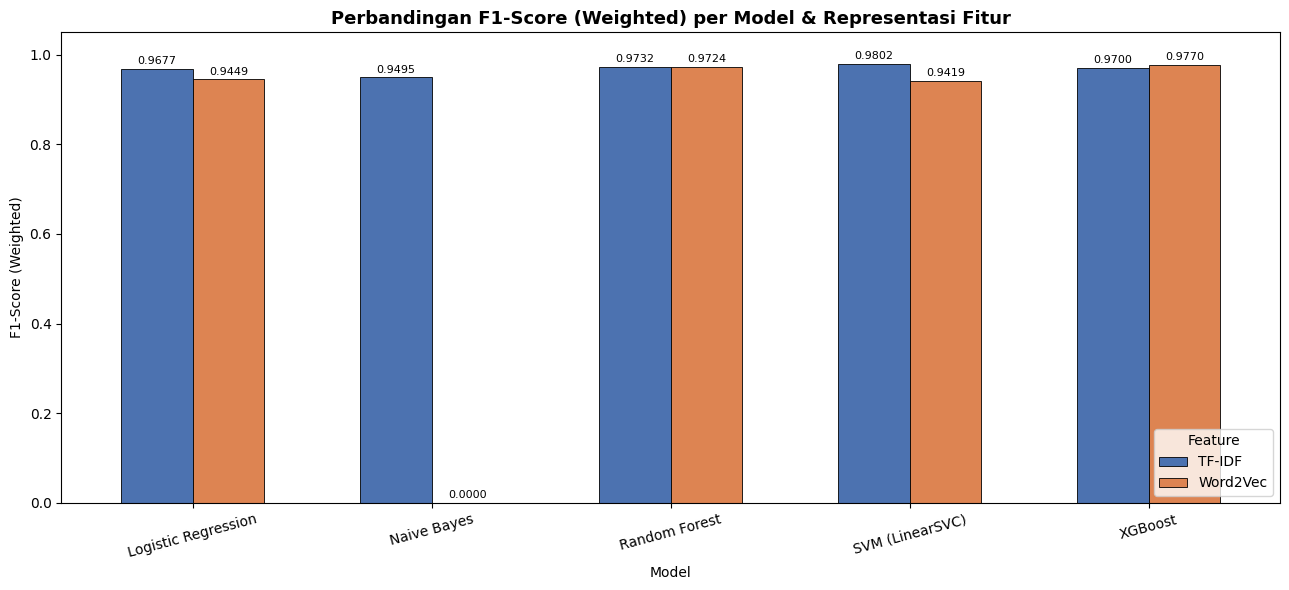

✅ Gambar disimpan: perbandingan_f1score.png


In [ ]:
# ── Bar Chart Perbandingan F1-Score ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

df_pivot = df_results.pivot(index='Model', columns='Feature', values='F1-Score')
df_pivot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black', linewidth=0.6, width=0.6)

ax.set_title('Perbandingan F1-Score (Weighted) per Model & Representasi Fitur',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Model')
ax.set_ylabel('F1-Score (Weighted)')
ax.set_ylim(0, 1.05)
ax.legend(title='Feature', loc='lower right')
ax.tick_params(axis='x', rotation=15)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('perbandingan_f1score.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: perbandingan_f1score.png')

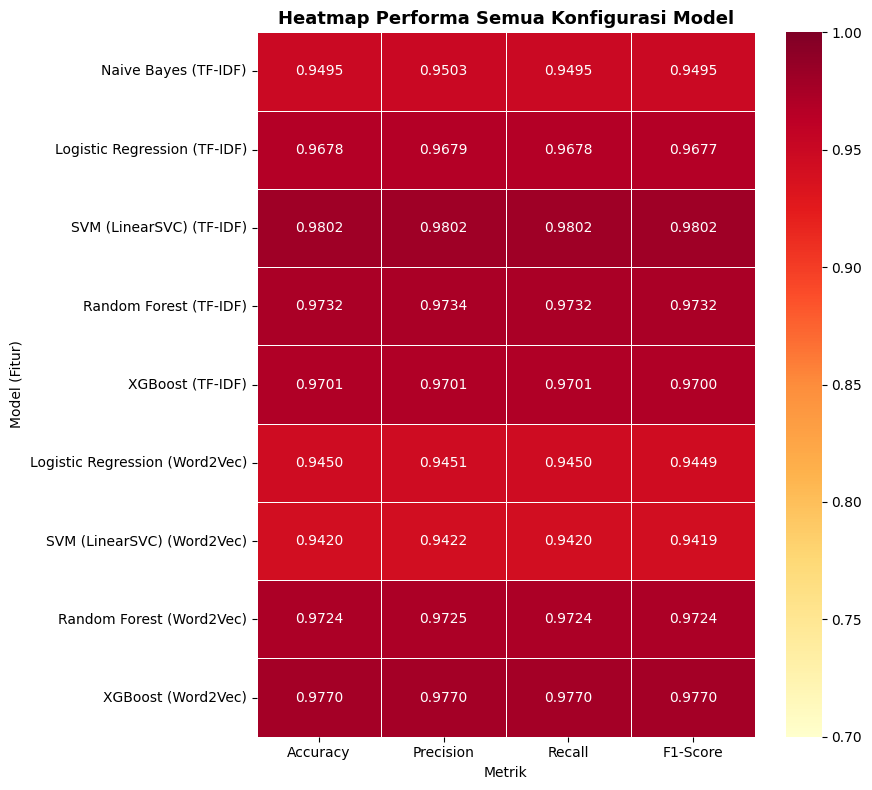

✅ Gambar disimpan: heatmap_performa.png


In [ ]:
# ── Heatmap Performa ──────────────────────────────────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
df_heat = df_results.copy()
df_heat['Model_Feature'] = df_heat['Model'] + ' (' + df_heat['Feature'] + ')'
df_heat = df_heat.set_index('Model_Feature')[metrics]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    df_heat,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0.7,
    vmax=1.0,
    ax=ax
)
ax.set_title('Heatmap Performa Semua Konfigurasi Model', fontsize=13, fontweight='bold')
ax.set_xlabel('Metrik')
ax.set_ylabel('Model (Fitur)')
plt.tight_layout()
plt.savefig('heatmap_performa.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: heatmap_performa.png')

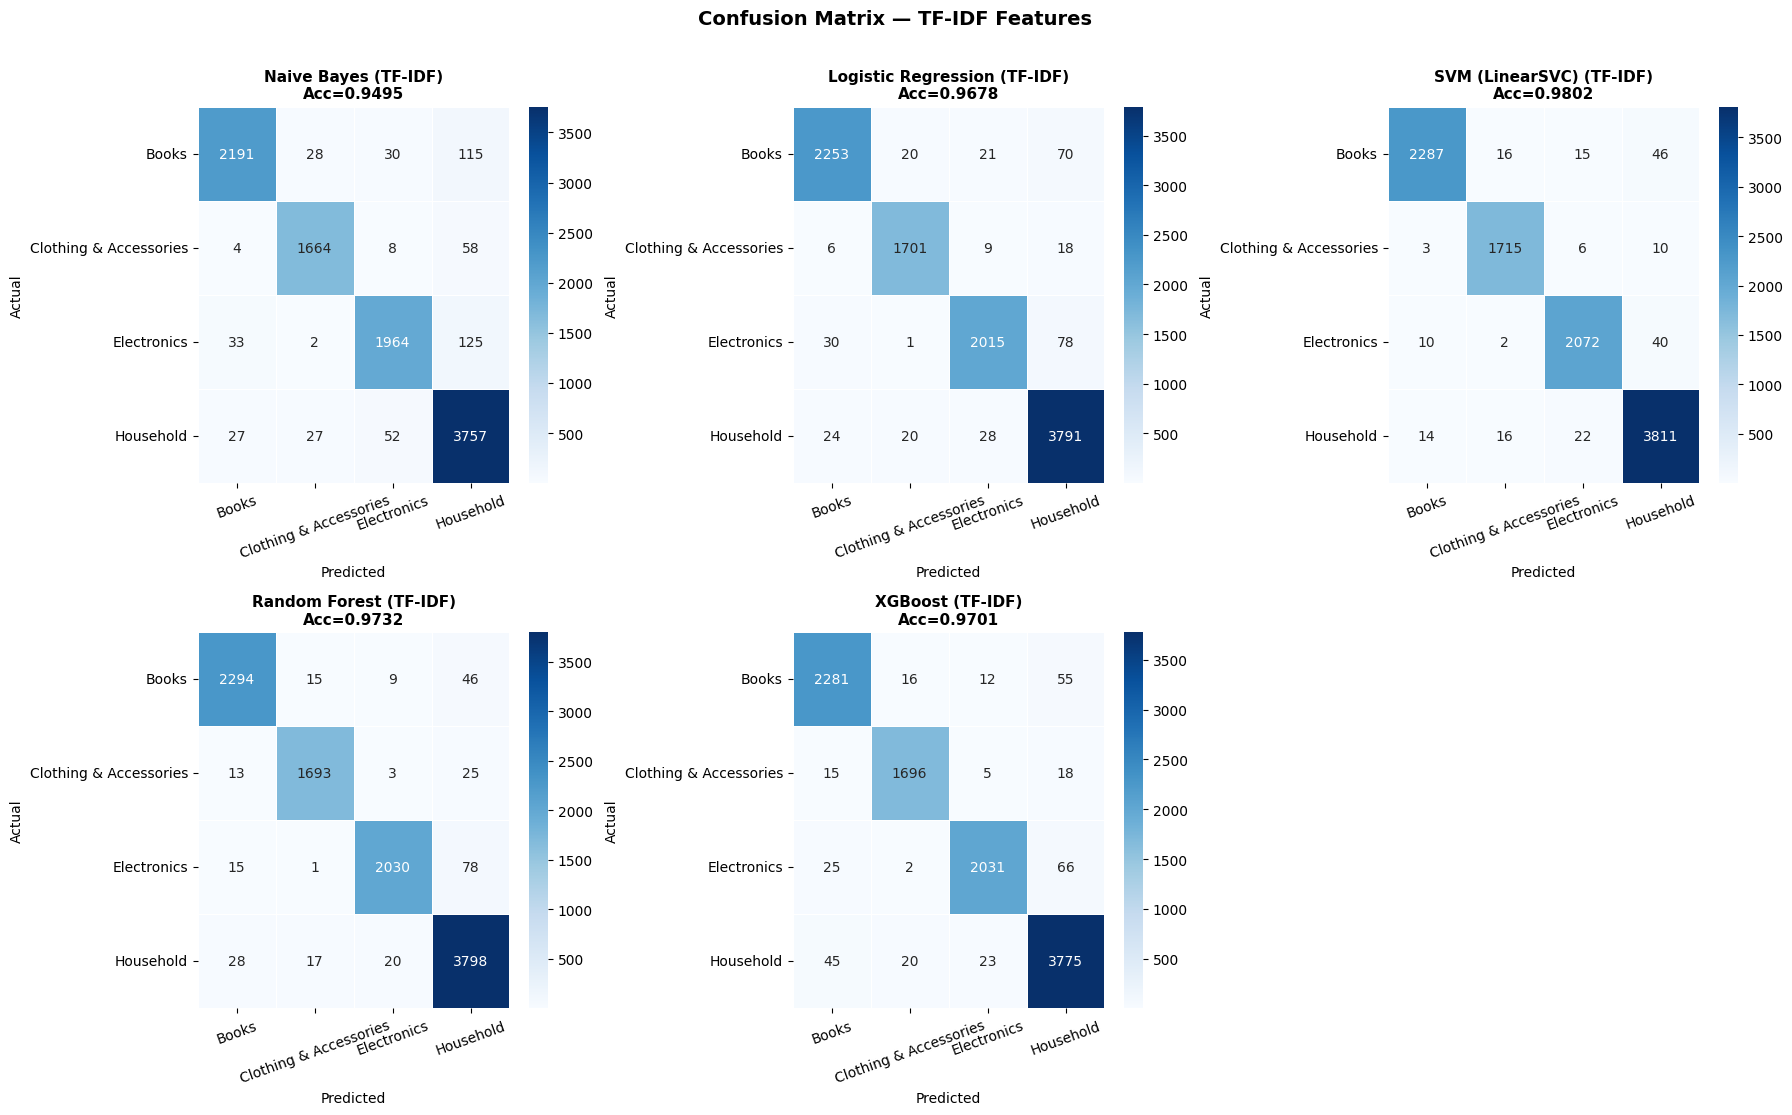

✅ Gambar disimpan: confusion_matrix_tfidf.png


In [ ]:
# ── Confusion Matrix untuk Setiap Model (TF-IDF) ─────────────────────────────
class_names = le.classes_
n_models    = len(results_tfidf)
fig, axes   = plt.subplots(2, 3, figsize=(18, 11))
axes        = axes.flatten()

for i, r in enumerate(results_tfidf):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i],
        linewidths=0.5
    )
    axes[i].set_title(f'{r["Model"]} (TF-IDF)\nAcc={r["Accuracy"]:.4f}',
                       fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=20)

# Sembunyikan subplot kosong
for j in range(n_models, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix — TF-IDF Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: confusion_matrix_tfidf.png')

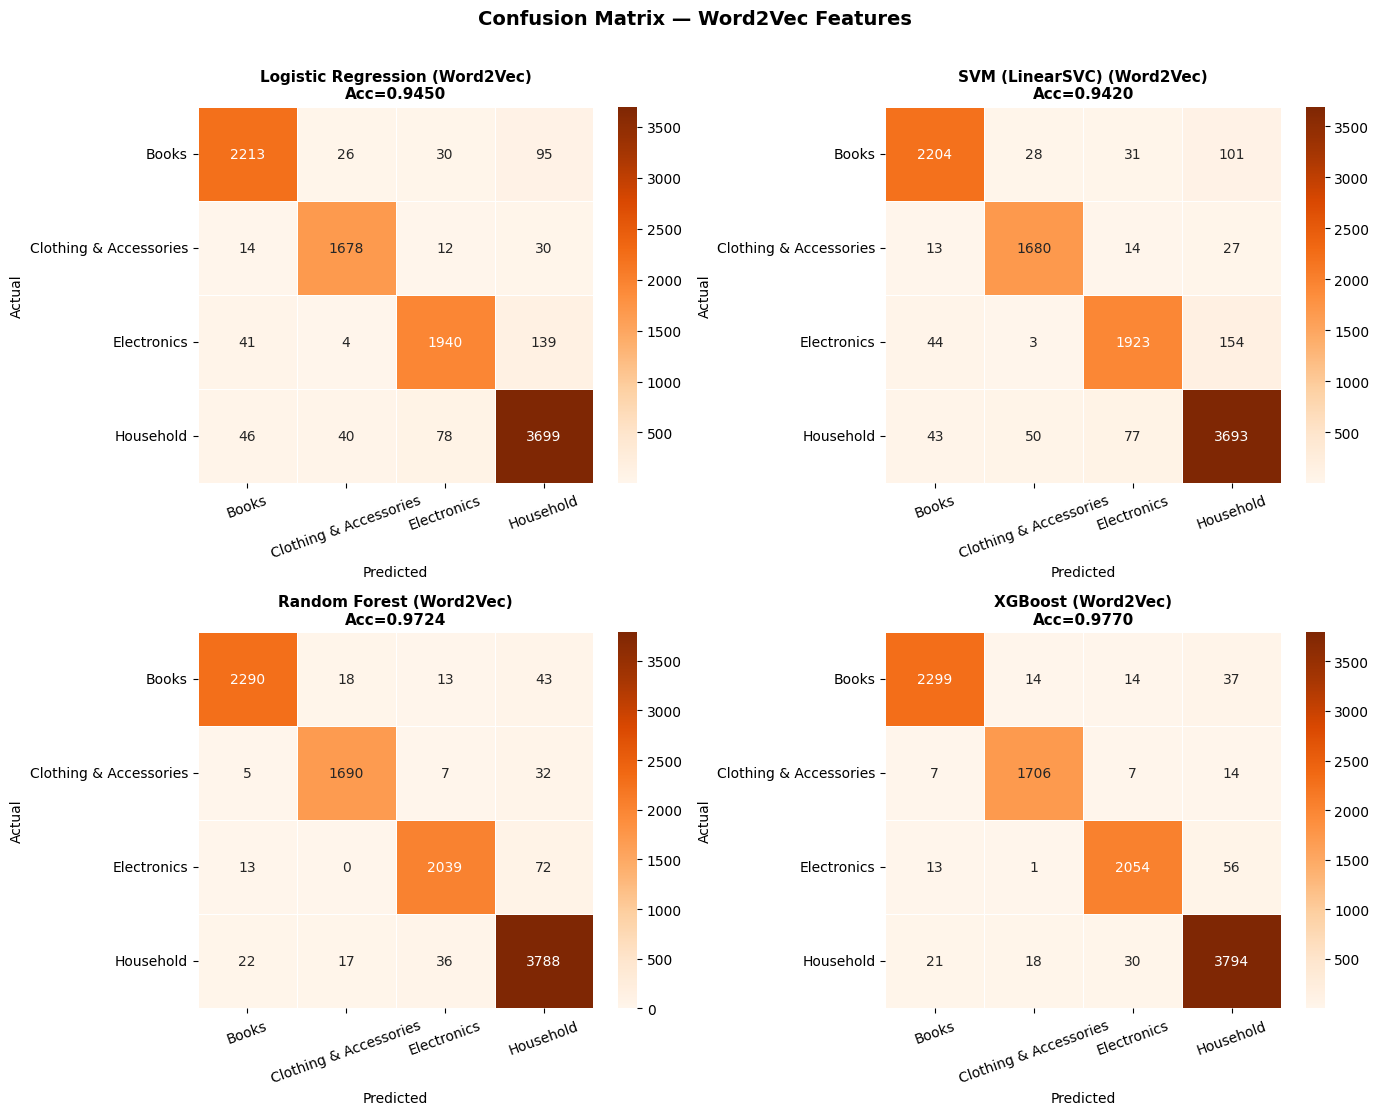

✅ Gambar disimpan: confusion_matrix_w2v.png


In [ ]:
# ── Confusion Matrix untuk Setiap Model (Word2Vec) ────────────────────────────
n_models_w2v = len(results_w2v)
fig, axes    = plt.subplots(2, 2, figsize=(14, 11))
axes         = axes.flatten()

for i, r in enumerate(results_w2v):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i],
        linewidths=0.5
    )
    axes[i].set_title(f'{r["Model"]} (Word2Vec)\nAcc={r["Accuracy"]:.4f}',
                       fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=20)

for j in range(n_models_w2v, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix — Word2Vec Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrix_w2v.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: confusion_matrix_w2v.png')

In [ ]:
# ── Classification Report — Model Terbaik (TF-IDF) ───────────────────────────
best_tfidf = max(results_tfidf, key=lambda x: x['F1-Score'])
print(f'Model Terbaik (TF-IDF): {best_tfidf["Model"]} | F1={best_tfidf["F1-Score"]:.4f}\n')
print(classification_report(y_test, best_tfidf['y_pred'], target_names=class_names))

Model Terbaik (TF-IDF): SVM (LinearSVC) | F1=0.9802

                        precision    recall  f1-score   support

                 Books       0.99      0.97      0.98      2364
Clothing & Accessories       0.98      0.99      0.98      1734
           Electronics       0.98      0.98      0.98      2124
             Household       0.98      0.99      0.98      3863

              accuracy                           0.98     10085
             macro avg       0.98      0.98      0.98     10085
          weighted avg       0.98      0.98      0.98     10085



In [ ]:
# ── Classification Report — Model Terbaik (Word2Vec) ─────────────────────────
best_w2v = max(results_w2v, key=lambda x: x['F1-Score'])
print(f'Model Terbaik (Word2Vec): {best_w2v["Model"]} | F1={best_w2v["F1-Score"]:.4f}\n')
print(classification_report(y_test, best_w2v['y_pred'], target_names=class_names))

Model Terbaik (Word2Vec): XGBoost | F1=0.9770

                        precision    recall  f1-score   support

                 Books       0.98      0.97      0.98      2364
Clothing & Accessories       0.98      0.98      0.98      1734
           Electronics       0.98      0.97      0.97      2124
             Household       0.97      0.98      0.98      3863

              accuracy                           0.98     10085
             macro avg       0.98      0.98      0.98     10085
          weighted avg       0.98      0.98      0.98     10085



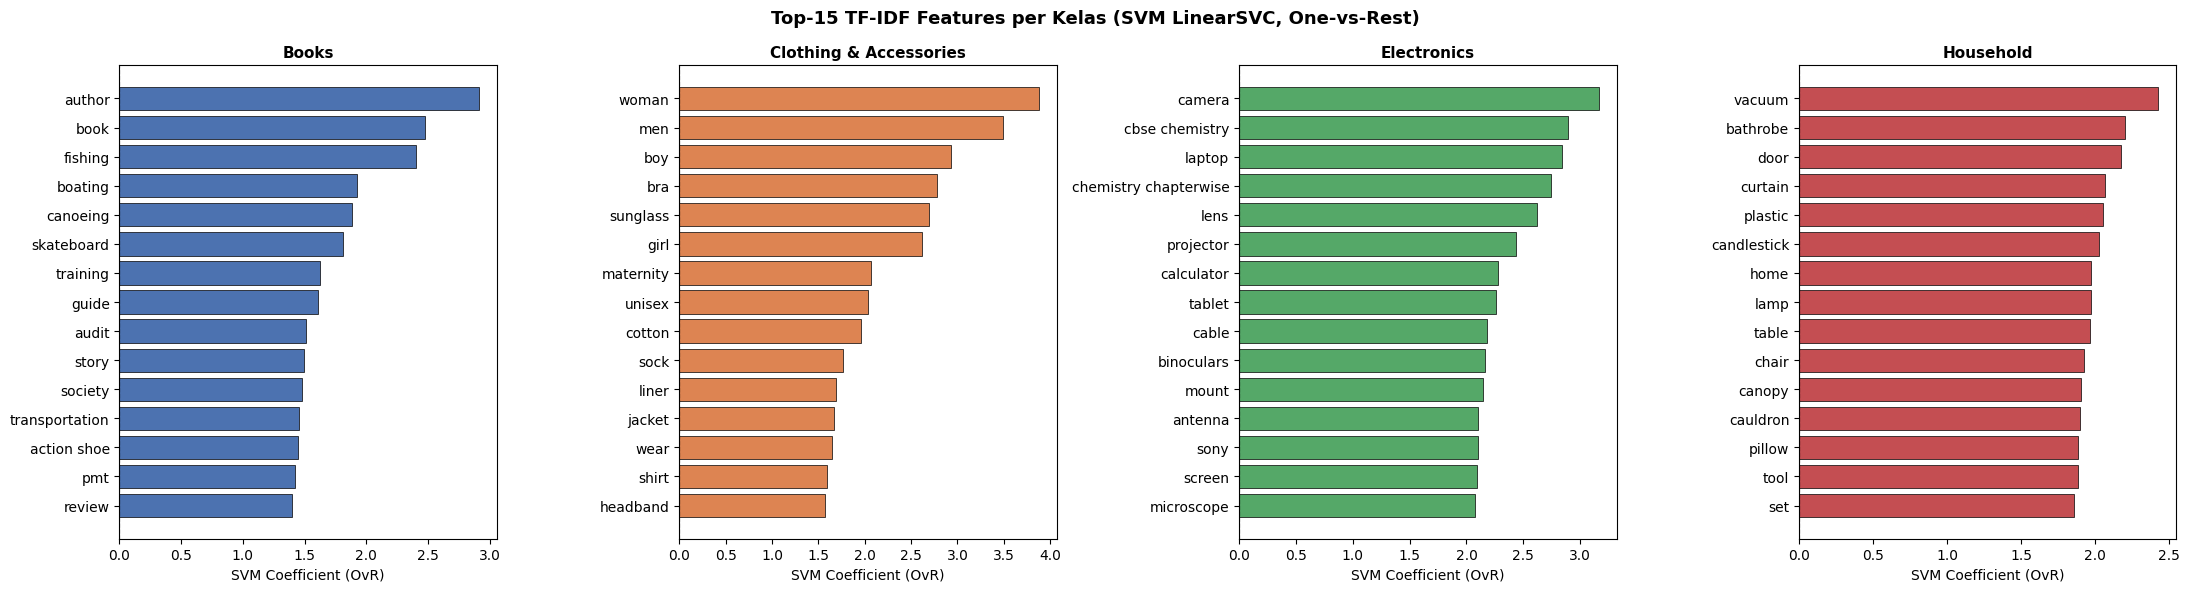

✅ Gambar disimpan: top_features_per_kelas.png


In [ ]:
# ── Top-10 TF-IDF Features per Kelas ─────────────────────────────────────────
# SVM sebagai contoh (karena model terbaik)

svm_check = [r for r in results_tfidf if r['Model'] == 'SVM (LinearSVC)']
if svm_check:
    # Re-train SVM untuk akses .coef_
    svm_for_features = LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)
    svm_for_features.fit(X_tfidf_train, y_train)
    feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    colors_bar = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

    for i, (cls, ax, bar_color) in enumerate(zip(class_names, axes, colors_bar)):
        coef      = svm_for_features.coef_[i]   # bobot fitur untuk kelas ke-i (OvR)
        top_idx   = np.argsort(coef)[-15:][::-1]
        top_feats = feature_names[top_idx]
        top_coefs = coef[top_idx]

        ax.barh(top_feats[::-1], top_coefs[::-1],
                color=bar_color, edgecolor='black', linewidth=0.5)
        ax.set_title(f'{cls}', fontsize=11, fontweight='bold')
        ax.set_xlabel('SVM Coefficient (OvR)')
        ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

    plt.suptitle('Top-15 TF-IDF Features per Kelas (SVM LinearSVC, One-vs-Rest)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('top_features_per_kelas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Gambar disimpan: top_features_per_kelas.png')
else:
    print('⚠️ Hasil SVM tidak ditemukan di results_tfidf.')

# Save Model

In [ ]:
import joblib

# Retrain SVM dengan TF-IDF (pastikan sudah fit)
svm_final = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_final.fit(X_tfidf_train, y_train)

# Simpan semua artefak
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')
joblib.dump(svm_final, 'svm_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("✅ Model, vectorizer, dan label encoder tersimpan!")

✅ Model, vectorizer, dan label encoder tersimpan!
